# المشروع 1 — تتبّع المركبات (Vehicle Tracking)
**YOLO11 + ByteTrack:** Detect → Track → Count → Speed → Trajectory

## شرح الـ notebook المقترح (Suggested Tracking & Surveillance Projects)
الفكرة العامة: الانتقال من «كشف الأشياء» إلى نظام كامل **detect → track → analyze → alert**. الملف يقترح 8 مشاريع:

| # | المشروع | الجديد الذي يتعلمه الطالب |
|---|---|---|
| 1 | تتبع كائنات من درون | IDs ثابتة، مسارات، تعويض حركة الكاميرا |
| 2 | مراقبة مرور من درون | عدّ، اتجاه، سرعة، سيارات متوقفة، سير عكسي |
| 3 | سلامة موقع بناء | علاقات مكانية وقواعد زمنية (خوذة، منطقة محظورة) |
| 4 | تتبع أشخاص وتحليل سلوك | مسارات ← سلوك (جري، تسكّع، سقوط) |
| 5 | بحث وإنقاذ بالدرون | كشف أجسام صغيرة، موقع GPS، عدم تكرار البلاغ |
| 6 | تتبع صناعي | زمن الدورة، نسبة العيوب |
| 7 | تقاطع ذكي بعدة كاميرات | Re-identification بين الكاميرات |
| 8 | درون ضد درون | أجسام صغيرة وسريعة |

**التسلسل المقترح:** مشروع 1 (تتبع مركبات، كاميرا ثابتة) ← مشروع 2 (درون + BoT-SORT + تعويض حركة الكاميرا) ← مشروع 3 (Re-ID + موقع جغرافي + تنبيهات). ويُعتبر Search-and-Rescue المشروع الختامي.

**هنا ننفّذ المشروع الأول**، لأنه أساس بقية المشاريع: نفس خط الأنابيب (Detection → Tracker → IDs/Trajectories → Scene Analysis → Alerts) يُعاد استخدامه لاحقًا.

## كيف يعمل النظام
| المطلوب | كيف نحققه |
|---|---|
| Detect | YOLO11 (فئات: car, motorcycle, bus, truck) |
| Track + IDs | ByteTrack عبر `model.track(..., persist=True)`. يربط الصناديق بين الإطارات بـ Kalman filter وIoU، ويستعمل أيضًا الصناديق منخفضة الثقة لتقليل ضياع الـ ID |
| Trajectory | نخزّن نقطة التماس مع الطريق (منتصف الحافة السفلية للصندوق) لكل ID ونرسم آخر 40 نقطة |
| Count | خط عدّ: تغيّر إشارة موقع النقطة بالنسبة للخط = عبور. كل مركبة تُعدّ مرة واحدة |
| Speed | المسافة بالبكسل خلال نافذة 1 ثانية × `M_PER_PX` ÷ الزمن |
| Direction | اتجاه متجه الإزاحة (أعلى الصورة = North) |
| Stopped | سرعة أقل من 3 كم/س لمدة 2 ثانية أو أكثر |
| Wrong-way | حركة عكس الاتجاه المسموح `ALLOWED_DIR` |
| Time in zone | عدد الإطارات داخل المضلع ÷ FPS |

> **تنبيه مهم عن السرعة:** الرقم يكون دقيقًا فقط بعد **معايرة** `M_PER_PX` (كم متر يمثله البكسل الواحد)، ويكون أفضل ما يمكن مع كاميرا علوية (درون بزاوية عمودية). مع منظور مائل يتغير المقياس بحسب بُعد المركبة، فتُعامل الأرقام كتقدير وليست قياسًا رسميًا.

## 1. التثبيت

In [ ]:
!pip install -q ultralytics opencv-python pandas matplotlib lap

## 2. الإعدادات
عدّل هذه القيم فقط. الخط والمنطقة مكتوبان كنِسَب من عرض/ارتفاع الفيديو (0–1) حتى تعمل مع أي دقة.

In [3]:
VIDEO      = r"C:\Users\PC-LAB1\Desktop\New folder\test_vedio\VID00051.AVI"        # path to your video (e.g. the Day-4 traffic clip)
OUT_VIDEO  = "vehicles_tracked.mp4"
OUT_CSV    = "vehicle_report.csv"

MODEL      = "yolo11n.pt"               # try yolo11s.pt for better accuracy
TRACKER    = "bytetrack.yaml"           # Project 2: "botsort.yaml"
CLASSES    = [2, 3, 5, 7]               # COCO: car, motorcycle, bus, truck
CONF, IMGSZ = 0.3, 640

# Counting line (two points) and analysis zone (polygon), as fractions of (width, height)
LINE_REL = ((0.05, 0.60), (0.95, 0.60))
ZONE_REL = [(0.05, 0.35), (0.95, 0.35), (0.95, 0.95), (0.05, 0.95)]

# Calibration: meters per pixel. Measure a known real distance in the image:
#   M_PER_PX = real_distance_in_meters / distance_in_pixels
M_PER_PX   = 0.05

ALLOWED_DIR = None                      # e.g. (0, -1) = traffic must move up (North); None = disabled
MAX_FRAMES  = None                      # e.g. 300 for a quick test; None = whole video
PREVIEW_FRAME = 120                     # frame saved for display at the end

## 3. وحدة التحليل (Scene Analysis)
هذا الجزء لا يحتاج YOLO: يستقبل (frame, ID, class, box) ويحسب العدّ والسرعة والاتجاه والتوقف. اختُبر على مسارات اصطناعية (سرعة معروفة، مركبة متوقفة، سير عكسي).

In [4]:
import math
from dataclasses import dataclass, field
import pandas as pd

def side_of_line(p, a, b):
    """>0 on one side of line a->b, <0 on the other, 0 on the line."""
    return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0])

def compass(dx, dy, min_move=2.0):
    """Image y grows downward, so 'up' in the image is treated as North."""
    if math.hypot(dx, dy) < min_move:
        return "-"
    ang = math.degrees(math.atan2(-dy, dx))
    names = ["East", "North-East", "North", "North-West",
             "West", "South-West", "South", "South-East"]
    return names[int(((ang + 22.5) % 360) // 45)]

def point_in_polygon(pt, polygon):
    """Ray casting; polygon = list of (x, y)."""
    x, y = pt
    inside = False
    n = len(polygon)
    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]
        if (y1 > y) != (y2 > y) and x < (x2 - x1) * (y - y1) / (y2 - y1) + x1:
            inside = not inside
    return inside

@dataclass
class Track:
    cls: str
    pts: list = field(default_factory=list)      # (frame, x, y)
    zone_frames: int = 0
    still_since: int = None
    stopped: bool = False
    wrong_way: bool = False
    counted: bool = False

class VehicleAnalytics:
    def __init__(self, fps, m_per_px, line=None, zone=None,
                 speed_window_s=1.0, stop_kmh=3.0, stop_secs=2.0, allowed_dir=None):
        self.fps, self.mpp = fps, m_per_px
        self.line, self.zone = line, zone
        self.win = speed_window_s
        self.stop_kmh, self.stop_secs = stop_kmh, stop_secs
        self.allowed_dir = allowed_dir            # e.g. (0, -1) = traffic should move up/North
        self.tracks = {}
        self.line_counts = {"A->B": 0, "B->A": 0}
        self.by_class = {}

    def update(self, frame_no, tid, cls_name, xyxy):
        x1, y1, x2, y2 = xyxy
        p = ((x1 + x2) / 2, y2)                   # bottom-center = contact point with the road
        t = self.tracks.setdefault(tid, Track(cls_name))
        prev = t.pts[-1] if t.pts else None
        t.pts.append((frame_no, p[0], p[1]))

        if self.zone and point_in_polygon(p, self.zone):
            t.zone_frames += 1

        if self.line and prev is not None and not t.counted:
            s0 = side_of_line(prev[1:], *self.line)
            s1 = side_of_line(p, *self.line)
            crossed_ab = s0 < 0 <= s1                # negative side -> positive side
            crossed_ba = s0 > 0 >= s1                # positive side -> negative side
            if crossed_ab or crossed_ba:
                self.line_counts["A->B" if crossed_ab else "B->A"] += 1
                self.by_class[cls_name] = self.by_class.get(cls_name, 0) + 1
                t.counted = True                  # count each vehicle once

        v = self.speed_kmh(tid)
        if self._age_s(t) >= self.win:
            if v < self.stop_kmh:
                if t.still_since is None:
                    t.still_since = frame_no
                if (frame_no - t.still_since) / self.fps >= self.stop_secs:
                    t.stopped = True
            else:
                t.still_since, t.stopped = None, False
        if self.allowed_dir is not None:
            dx, dy = self.displacement(tid)
            if math.hypot(dx, dy) > 30 and dx * self.allowed_dir[0] + dy * self.allowed_dir[1] < 0:
                t.wrong_way = True
        return v

    def _age_s(self, t):
        return (t.pts[-1][0] - t.pts[0][0]) / self.fps

    def _window(self, tid):
        pts = self.tracks[tid].pts
        f_now = pts[-1][0]
        for q in pts:
            if f_now - q[0] <= self.win * self.fps:
                return q, pts[-1]
        return pts[0], pts[-1]

    def speed_kmh(self, tid):
        a, b = self._window(tid)
        dt = (b[0] - a[0]) / self.fps
        if dt <= 0:
            return 0.0
        dist_px = math.hypot(b[1] - a[1], b[2] - a[2])
        return dist_px * self.mpp / dt * 3.6

    def displacement(self, tid):
        pts = self.tracks[tid].pts
        return pts[-1][1] - pts[0][1], pts[-1][2] - pts[0][2]

    def report(self, min_frames=15):
        rows = []
        for tid, t in self.tracks.items():
            if len(t.pts) < min_frames:           # ignore very short (likely spurious) tracks
                continue
            dx, dy = self.displacement(tid)
            speeds = [self._speed_at(t, i) for i in range(len(t.pts))]
            moving = [s for s in speeds if s >= self.stop_kmh]
            rows.append({
                "Vehicle ID": tid, "Type": t.cls, "Direction": compass(dx, dy),
                "Avg speed (km/h)": round(sum(moving) / len(moving), 1) if moving else 0.0,
                "Max speed (km/h)": round(max(speeds), 1),
                "Time in zone (s)": round(t.zone_frames / self.fps, 1),
                "Counted at line": t.counted,
                "Stopped": t.stopped, "Wrong way": t.wrong_way,
            })
        return pd.DataFrame(rows)

    def _speed_at(self, t, i):
        f_now = t.pts[i][0]
        j = i
        while j > 0 and f_now - t.pts[j - 1][0] <= self.win * self.fps:
            j -= 1
        a, b = t.pts[j], t.pts[i]
        dt = (b[0] - a[0]) / self.fps
        if dt <= 0:
            return 0.0
        return math.hypot(b[1] - a[1], b[2] - a[2]) * self.mpp / dt * 3.6

## 4. فتح الفيديو ومعاينة الخط والمنطقة
تأكد أن الخط الأخضر يقطع الطريق وأن المنطقة تغطيه، قبل تشغيل المعالجة الكاملة.

640x480 @ 25.0 fps


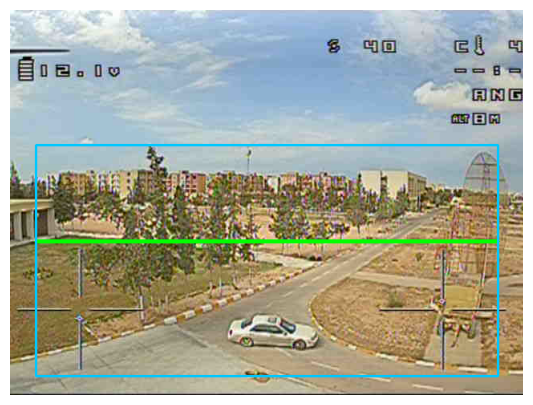

True

In [5]:
import cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

cap = cv2.VideoCapture(VIDEO)
assert cap.isOpened(), f"Cannot open video: {VIDEO}"
fps = cap.get(cv2.CAP_PROP_FPS) or 25
W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
LINE = tuple((int(x * W), int(y * H)) for x, y in LINE_REL)
ZONE = [(int(x * W), int(y * H)) for x, y in ZONE_REL]
print(f"{W}x{H} @ {fps:.1f} fps")

ok, first = cap.read()
prev = first.copy()
cv2.line(prev, LINE[0], LINE[1], (0, 255, 0), 3)
cv2.polylines(prev, [np.array(ZONE, np.int32)], True, (255, 200, 0), 2)
plt.figure(figsize=(9, 5)); plt.imshow(cv2.cvtColor(prev, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

## 5. المعالجة الكاملة: Detect → Track → Analyze → Annotate

In [6]:
model = YOLO(MODEL)
va = VehicleAnalytics(fps, M_PER_PX, line=LINE, zone=ZONE, allowed_dir=ALLOWED_DIR)
writer = cv2.VideoWriter(OUT_VIDEO, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

frame_no, sample = 0, None
while True:
    ok, frame = cap.read()
    if not ok or (MAX_FRAMES and frame_no >= MAX_FRAMES):
        break
    frame_no += 1

    r = model.track(frame, persist=True, tracker=TRACKER, classes=CLASSES,
                    conf=CONF, imgsz=IMGSZ, verbose=False)[0]

    if r.boxes.id is not None:                       # ids are None when nothing is tracked
        ids   = r.boxes.id.int().cpu().tolist()
        boxes = r.boxes.xyxy.cpu().numpy()
        clss  = r.boxes.cls.int().cpu().tolist()
        for tid, box, c in zip(ids, boxes, clss):
            name = r.names[c]
            v = va.update(frame_no, tid, name, box.tolist())
            t = va.tracks[tid]
            alert = t.stopped or t.wrong_way
            color = (0, 0, 255) if alert else (0, 200, 0)

            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            label = f"#{tid} {name} {v:.0f}km/h"
            label += " STOPPED" if t.stopped else ""
            label += " WRONG-WAY" if t.wrong_way else ""
            cv2.putText(frame, label, (x1, max(y1 - 6, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            trail = np.array([(int(p[1]), int(p[2])) for p in t.pts[-40:]], np.int32)
            if len(trail) > 1:
                cv2.polylines(frame, [trail], False, color, 2)

    # overlay: line, zone, counters
    cv2.line(frame, LINE[0], LINE[1], (0, 255, 0), 3)
    cv2.polylines(frame, [np.array(ZONE, np.int32)], True, (255, 200, 0), 1)
    hud = [f"Frame: {frame_no}",
           f"A->B: {va.line_counts['A->B']}   B->A: {va.line_counts['B->A']}",
           "  ".join(f"{k}: {n}" for k, n in va.by_class.items())]
    for i, line in enumerate(hud):
        cv2.putText(frame, line, (10, 25 + 24 * i), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    writer.write(frame)
    if frame_no == PREVIEW_FRAME:
        sample = frame.copy()

cap.release(); writer.release()
print(f"Done: {frame_no} frames -> {OUT_VIDEO}")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for lap>=0.5.12 from https://files.pythonhosted.org/packages/b8/c7/cfd1b2274c00aba8513c0fa385c7e71790a9f44d7d23f5cdbcd94a895c06/lap-0.5.13-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 640.0 kB/s eta 0:00:03
   - -------------------------------------- 0.1/1.5 MB 787.7 kB/s eta 0:00:02
   -- ------------------------------------- 0.1/1.5 MB 980.4 kB/s eta 0:00:02
   ---- ----------------------------------- 0.2/1.5 MB 1.0 MB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.5 MB 1.1 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.5 MB 1.1 MB/s eta 0:00:02
   --------- ----------

## 6. النتائج: الجدول والتنبيهات

,Vehicle ID,Type,Direction,Avg speed (km/h),Max speed (km/h),Time in zone (s),Counted at line,Stopped,Wrong way
0,1,car,North-West,16.3,69.7,2.7,True,False,False
1,9,car,North-East,5.0,6.2,0.8,True,False,False
2,12,car,South-East,6.4,13.6,3.8,False,False,False
3,15,car,West,4.5,7.4,1.9,False,False,False
4,25,car,East,4.3,5.1,1.0,False,False,False
5,121,car,South,5.8,10.4,0.6,True,False,False
6,330,car,South,9.6,17.3,0.6,False,False,False
7,338,car,South,11.8,21.1,0.8,False,False,False
8,340,car,South-East,13.7,33.6,2.2,False,False,False
9,351,car,North-East,14.1,29.3,0.4,False,False,False


Line counts : {'A->B': 3, 'B->A': 4} | by class: {'car': 7}


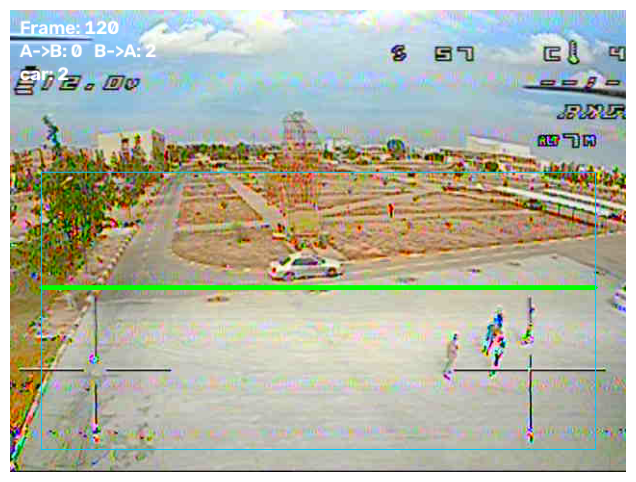

In [7]:
df = va.report()
df.to_csv(OUT_CSV, index=False)
display(df.sort_values("Vehicle ID").reset_index(drop=True))

print("Line counts :", va.line_counts, "| by class:", va.by_class)
for _, row in df[df["Stopped"]].iterrows():
    print(f"ALERT: vehicle #{row['Vehicle ID']} ({row['Type']}) is stopped")
for _, row in df[df["Wrong way"]].iterrows():
    print(f"ALERT: vehicle #{row['Vehicle ID']} ({row['Type']}) moving the wrong way")

if sample is not None:
    plt.figure(figsize=(10, 6)); plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

## 7. ملاحظات وخطوات تالية
- **ID switches:** إذا تغيّر رقم مركبة بعد اختفائها خلف عائق فهذا سلوك متوقع من tracker بسيط. جرّب `botsort.yaml` أو `yolo11s.pt` أو خفّض `CONF` قليلًا.
- **تقارير قصيرة:** `report(min_frames=15)` يتجاهل المسارات الأقصر من 15 إطارًا (غالبًا كشف خاطئ).
- **التقييم:** لمعرفة دقة العدّ قارن `va.line_counts` بعدّ يدوي على مقطع 1–2 دقيقة. لا تعتمد على الفيديو المرسوم وحده.
- **المشروع 2 (درون):** غيّر `TRACKER = "botsort.yaml"` (يدعم تعويض حركة الكاميرا)، واحسب المسارات بعد تصحيح الحركة بـ optical flow أو homography.
- **المشروع 3:** أضف Re-ID، وتحويل البكسل إلى إحداثيات جغرافية، ونظام تنبيهات (ملف/رسالة).

In [8]:
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import torch
from ultralytics import YOLO

# ============ الإعدادات ============
VIDEO_PATH = r"C:\Users\PC-LAB1\Desktop\New folder\test_vedio\VID00051.mp4"
OUTPUT_PATH = r"C:\Users\PC-LAB1\Desktop\New folder\test_vedio\cars_tracked.mp4"
MODEL_PATH = "yolo11m.pt"        # yolo11n أسرع | yolo11m أدق
CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.5
IMG_SIZE = 400                   # حجم أكبر = كشف أفضل للسيارات البعيدة
VEHICLE_CLASSES = [2, 3, 5, 7]   # car, motorcycle, bus, truck
TRAIL_LENGTH = 40
SHOW_LIVE = True                 # اضغط q للخروج

# خط العدّ (نسبة من ارتفاع الفيديو). ضع None لإلغائه
COUNT_LINE_Y_RATIO = 0.6
# ===================================

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ---- عرض مباشر آمن: نافذة OpenCV إن أمكن، وإلا داخل Jupyter ----
_use_cv_window = True


def show_frame(frame, frame_idx):
    """يعرض الإطار. returns True إذا طلب المستخدم الخروج."""
    global _use_cv_window
    if _use_cv_window:
        try:
            cv2.imshow("Vehicle Tracking", frame)
            return (cv2.waitKey(1) & 0xFF) == ord("q")
        except cv2.error:
            # نسخة OpenCV بدون دعم النوافذ -> التحويل للعرض داخل Jupyter
            _use_cv_window = False
            print("OpenCV بدون نوافذ، سيتم العرض داخل Jupyter.")
    if frame_idx % 3 == 0:                      # عرض كل 3 إطارات لتخفيف الحمل
        from IPython.display import display, clear_output
        from PIL import Image
        clear_output(wait=True)
        display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    return False

# ألوان ثابتة لكل ID
def color_for(track_id: int):
    rng = np.random.RandomState(track_id * 7 + 3)
    return tuple(int(x) for x in rng.randint(60, 255, 3))


def main():
    if not Path(VIDEO_PATH).exists():
        raise FileNotFoundError(f"الفيديو غير موجود: {VIDEO_PATH}")

    model = YOLO(MODEL_PATH)
    names = model.names

    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    writer = cv2.VideoWriter(
        OUTPUT_PATH, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h)
    )

    line_y = int(h * COUNT_LINE_Y_RATIO) if COUNT_LINE_Y_RATIO else None

    unique_ids = defaultdict(set)      # الصنف -> IDs الفريدة
    trails = defaultdict(list)         # ID -> المسار
    last_cy = {}                       # ID -> آخر موضع رأسي
    counted = set()                    # IDs التي عبرت الخط
    crossed = defaultdict(int)         # الصنف -> عدد العابرين
    frame_idx = 0

    results = model.track(
        source=VIDEO_PATH,
        stream=True,
        persist=True,
        tracker="bytetrack.yaml",
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        imgsz=IMG_SIZE,
        classes=VEHICLE_CLASSES,
        device=DEVICE,
        half=(DEVICE != "cpu"),
        verbose=False,
    )

    for r in results:
        frame_idx += 1
        frame = r.orig_img.copy()
        current = defaultdict(int)

        if r.boxes is not None and r.boxes.id is not None:
            ids = r.boxes.id.int().cpu().tolist()
            clss = r.boxes.cls.int().cpu().tolist()
            confs = r.boxes.conf.cpu().tolist()
            xyxy = r.boxes.xyxy.cpu().numpy().astype(int)

            for tid, c, cf, (x1, y1, x2, y2) in zip(ids, clss, confs, xyxy):
                label = names[c]
                col = color_for(tid)
                unique_ids[label].add(tid)
                current[label] += 1

                # الصندوق + التسمية
                cv2.rectangle(frame, (x1, y1), (x2, y2), col, 2)
                text = f"#{tid} {label} {cf:.2f}"
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
                cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 6, y1), col, -1)
                cv2.putText(frame, text, (x1 + 3, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)

                # مسار الحركة (من منتصف أسفل الصندوق)
                cx, cy = (x1 + x2) // 2, y2
                trails[tid].append((cx, cy))
                trails[tid] = trails[tid][-TRAIL_LENGTH:]
                pts = np.array(trails[tid], dtype=np.int32)
                if len(pts) > 1:
                    cv2.polylines(frame, [pts], False, col, 2)
                cv2.circle(frame, (cx, cy), 4, col, -1)

                # عدّ العبور
                if line_y is not None and tid in last_cy and tid not in counted:
                    prev = last_cy[tid]
                    if (prev < line_y <= cy) or (prev > line_y >= cy):
                        counted.add(tid)
                        crossed[label] += 1
                last_cy[tid] = cy

        # خط العدّ
        if line_y is not None:
            cv2.line(frame, (0, line_y), (w, line_y), (0, 0, 255), 2)

        # لوحة المعلومات
        rows = max(len(unique_ids), 1)
        panel_h = 50 + 25 * rows
        overlay = frame.copy()
        cv2.rectangle(overlay, (10, 10), (400, panel_h), (0, 0, 0), -1)
        frame = cv2.addWeighted(overlay, 0.55, frame, 0.45, 0)

        cv2.putText(frame, f"Frame {frame_idx}/{total}", (20, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y = 62
        for label, ids_set in sorted(unique_ids.items()):
            txt = f"{label}: now={current[label]} total={len(ids_set)}"
            if line_y is not None:
                txt += f" crossed={crossed[label]}"
            cv2.putText(frame, txt, (20, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
            y += 25

        writer.write(frame)

        if SHOW_LIVE and show_frame(frame, frame_idx):
            break

    writer.release()
    try:
        cv2.destroyAllWindows()
    except cv2.error:
        pass

    print("\n========== التقرير النهائي ==========")
    print(f"الإطارات المعالجة: {frame_idx}")
    for label, ids_set in sorted(unique_ids.items(), key=lambda x: -len(x[1])):
        line = f"  {label:<12}: {len(ids_set)} مركبة فريدة"
        if line_y is not None:
            line += f" | عبرت الخط: {crossed[label]}"
        print(line)
    print(f"\nتم حفظ الفيديو في: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()

WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING imgsz=[400] must be multiple of max stride 32, updating to [416]

========== التقرير النهائي ==========
الإطارات المعالجة: 618
  car         : 10 مركبة فريدة | عبرت الخط: 3
  truck       : 1 مركبة فريدة | عبرت الخط: 0

تم حفظ الفيديو في: C:\Users\PC-LAB1\Desktop\New folder\test_vedio\cars_tracked.mp4


In [10]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Program Files\Python312\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Program Files\Python312\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "C:\Program Files\Python312\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "C:\Program Files\Python312\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Program Files\Python312\Lib\site-packages\pip\_vendor\tenacity\__init__.py", line 291, in wrapped_f
    return self(f, *args, **kw)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-pack

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for opencv-python==4.10.0.84 from https://files.pythonhosted.org/packages/ec/6c/fab8113424af5049f85717e8e527ca3773299a3c6b02506e66436e19874f/opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB 660.6 kB/s eta 0:00:59
   ---------------------------------------- 0.1/38.8 MB 653.6 kB/s eta 0:01:00
   ---------------------------------------- 0.1/38.8 MB 798.9 kB/s eta 0:00:49
   ---------------------------------------- 0.2/38.8 MB 952.6 kB/s eta 0:00:41
   ---------------------------------------- 0.2/38.8 MB 1.0 MB/s eta 0:00:38
   ---------------------------------------- 0.3/38.8 MB 1.1 MB/s eta 0:00:37
   ---------------------------------------- 0.4/38.8 MB 1.1 MB/s eta 0:00:37
  


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
"""
نظام تتبع احترافي للأشخاص والمركبات (YOLO11 + BoT-SORT/ByteTrack)

المزايا:
- تتبع أشخاص + سيارات + دراجات نارية + حافلات + شاحنات بـ ID ثابت
- تصويت على الصنف عبر الزمن (يمنع تبدل الصنف بين car/truck مثلاً)
- صناديق شبحية للأجسام المفقودة مؤقتاً + تنعيم الصناديق
- عدّ العبور عند خط مع الاتجاه (down/up) لكل مجموعة
- تصدير CSV بكل المسارات + فيديو ناتج + تقرير نهائي
- يعمل مع الأوزان الجاهزة أو أوزانك المدربة (يقرأ الأسماء من الموديل)
"""
from __future__ import annotations

import csv
import time
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import torch
from ultralytics import YOLO

# ============================ الإعدادات ============================
VIDEO_PATH = r"C:\Users\PC-LAB1\Desktop\New folder\test_vedio\VID00051.mp4"
OUTPUT_DIR = Path(r"C:\Users\PC-LAB1\Desktop\New folder\test_vedio\output")

MODEL_PATH = "yolo11m.pt"     # أو مسار best.pt المدرب. للسرعة: yolo11s / yolo11n
IMG_SIZE = 1280               # للأشخاص والسيارات البعيدة. قلّله (960/640) للسرعة

# اسم الصنف في الموديل -> المجموعة (تُستخدم للعدّ والألوان)
TARGETS = {
    "person": "person",
    "car": "vehicle",
    "motorcycle": "vehicle",
    "bus": "vehicle",
    "truck": "vehicle",
    # "bicycle": "vehicle",     # فعّلها إذا أردت الدراجات الهوائية
}
GROUP_COLORS = {              # BGR
    "person": (80, 220, 80),
    "vehicle": (0, 150, 255),
}

# --- جودة التتبع ---
DETECT_CONF = 0.15            # منخفض عمداً ليلتقط التتبع الكشوفات الضعيفة
NMS_IOU = 0.6
TRACKER_TYPE = "botsort"      # botsort (يعوّض حركة الكاميرا) أو bytetrack
TRACK_BUFFER = 90             # إطارات الاحتفاظ بالمسار بعد فقد الجسم
GHOST_FRAMES = 20             # مدة رسم الصندوق المتوقع للجسم المفقود
BOX_SMOOTH = 0.6              # تنعيم الصناديق (0 = بدون)
MIN_HITS = 3                  # أقل عدد مرات ظهور قبل اعتماد الجسم (يمنع الـ IDs الكاذبة)
MIN_CONF_DISPLAY = 0.25       # لا تُعرض الصناديق الأضعف من هذه الثقة

# --- العرض والمخرجات ---
TRAIL_LENGTH = 40
COUNT_LINE_Y_RATIO = 0.6      # ارتفاع خط العدّ (نسبة)، أو None لإلغائه
SHOW_LIVE = True              # q للخروج (أو Stop في Jupyter)
SAVE_CSV = True
# ==================================================================

DEVICE = 0 if torch.cuda.is_available() else "cpu"


# ---------------------------- أدوات مساعدة ----------------------------
def write_tracker_yaml(path: Path) -> str:
    common = (
        f"track_high_thresh: 0.30\n"
        f"track_low_thresh: 0.10\n"
        f"new_track_thresh: 0.35\n"
        f"track_buffer: {TRACK_BUFFER}\n"
        f"match_thresh: 0.85\n"
        f"fuse_score: True\n"
    )
    if TRACKER_TYPE == "botsort":
        text = (
            "tracker_type: botsort\n" + common +
            "gmc_method: sparseOptFlow\n"
            "proximity_thresh: 0.5\n"
            "appearance_thresh: 0.8\n"
            "with_reid: False\n"
            "model: auto\n"          # مطلوب في إصدارات ultralytics الحديثة
        )
    else:
        text = "tracker_type: bytetrack\n" + common
    path.write_text(text)
    return str(path)


_use_cv_window = True


def show_frame(frame: np.ndarray, frame_idx: int) -> bool:
    """عرض مباشر: نافذة OpenCV أو داخل Jupyter. يرجع True عند طلب الخروج."""
    global _use_cv_window
    if _use_cv_window:
        try:
            cv2.imshow("Tracking", frame)
            return (cv2.waitKey(1) & 0xFF) == ord("q")
        except cv2.error:
            _use_cv_window = False
            print("OpenCV بدون نوافذ، سيتم العرض داخل Jupyter.")
    if frame_idx % 3 == 0:
        from IPython.display import clear_output, display
        from PIL import Image
        clear_output(wait=True)
        display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    return False


def draw_dashed_rect(img, p1, p2, color, thickness=2, dash=8):
    x1, y1 = p1
    x2, y2 = p2
    for x in range(x1, x2, dash * 2):
        cv2.line(img, (x, y1), (min(x + dash, x2), y1), color, thickness)
        cv2.line(img, (x, y2), (min(x + dash, x2), y2), color, thickness)
    for y in range(y1, y2, dash * 2):
        cv2.line(img, (x1, y), (x1, min(y + dash, y2)), color, thickness)
        cv2.line(img, (x2, y), (x2, min(y + dash, y2)), color, thickness)


def draw_label(img, text, x, y, color):
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    y0 = max(y - th - 8, 0)
    cv2.rectangle(img, (x, y0), (x + tw + 6, y0 + th + 8), color, -1)
    cv2.putText(img, text, (x + 3, y0 + th + 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)


# ------------------------------- البرنامج -------------------------------
def main():
    if not Path(VIDEO_PATH).exists():
        parent = Path(VIDEO_PATH).parent
        hint = ""
        if parent.exists():
            vids = [p.name for p in parent.iterdir()
                    if p.suffix.lower() in {".avi", ".mp4", ".mov", ".mkv", ".wmv"}]
            hint = f"\nالفيديوهات الموجودة في المجلد: {vids}" if vids else "\nالمجلد موجود لكن لا يحتوي فيديوهات."
        else:
            hint = f"\nالمجلد نفسه غير موجود: {parent}"
        raise FileNotFoundError(f"الفيديو غير موجود: {VIDEO_PATH}{hint}")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    model = YOLO(MODEL_PATH)
    names = model.names
    class_ids = [i for i, n in names.items() if n in TARGETS]
    if not class_ids:
        raise ValueError("لا توجد أصناف مطابقة في TARGETS ضمن هذا الموديل.")
    print("الأصناف المتتبعة:", {i: names[i] for i in class_ids})

    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    out_video = OUTPUT_DIR / "tracked.mp4"
    writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    tracker_cfg = write_tracker_yaml(OUTPUT_DIR / "tracker_cfg.yaml")
    line_y = int(h * COUNT_LINE_Y_RATIO) if COUNT_LINE_Y_RATIO else None

    csv_file = csv_writer = None
    if SAVE_CSV:
        csv_file = open(OUTPUT_DIR / "tracks.csv", "w", newline="", encoding="utf-8")
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(["frame", "time_s", "id", "class", "group",
                             "conf", "x1", "y1", "x2", "y2"])

    # ---- الحالة ----
    state: dict[int, dict] = {}                    # ID -> بيانات الحالية
    hits: dict[int, int] = defaultdict(int)
    votes: dict[int, Counter] = defaultdict(Counter)
    id_group: dict[int, str] = {}
    unique = defaultdict(set)                      # group -> IDs مؤكدة
    class_unique = defaultdict(set)                # class -> IDs مؤكدة
    trails: dict[int, list] = defaultdict(list)
    last_cy: dict[int, int] = {}
    counted: set[int] = set()
    crossings = defaultdict(int)                   # (group, direction) -> عدد

    results = model.track(
        source=VIDEO_PATH, stream=True, persist=True, tracker=tracker_cfg,
        conf=DETECT_CONF, iou=NMS_IOU, imgsz=IMG_SIZE, classes=class_ids,
        device=DEVICE, half=(DEVICE != "cpu"), verbose=False,
    )

    frame_idx = 0
    t_prev = time.time()
    fps_ema = 0.0
    stopped = False

    try:
        for r in results:
            frame_idx += 1
            frame = r.orig_img.copy()
            current = defaultdict(int)

            # ---------- تحديث الحالة ----------
            if r.boxes is not None and r.boxes.id is not None:
                ids = r.boxes.id.int().cpu().tolist()
                clss = r.boxes.cls.int().cpu().tolist()
                confs = r.boxes.conf.cpu().tolist()
                boxes = r.boxes.xyxy.cpu().numpy().astype(float)

                for tid, c, cf, box in zip(ids, clss, confs, boxes):
                    hits[tid] += 1
                    votes[tid][names[c]] += 1
                    label = votes[tid].most_common(1)[0][0]      # تصويت الأغلبية
                    group = TARGETS[label]
                    id_group[tid] = group

                    if tid in state:
                        old = state[tid]
                        gap = max(frame_idx - old["last"], 1)
                        smooth = old["box"] * BOX_SMOOTH + box * (1 - BOX_SMOOTH)
                        vel = old["vel"] * 0.7 + ((box - old["box"]) / gap) * 0.3
                    else:
                        smooth, vel = box.copy(), np.zeros(4)

                    state[tid] = dict(box=smooth, vel=vel, last=frame_idx,
                                      label=label, group=group, conf=cf)

                    if hits[tid] >= MIN_HITS and cf >= MIN_CONF_DISPLAY:
                        unique[group].add(tid)
                        class_unique[label].add(tid)
                        current[group] += 1
                        if csv_writer:
                            x1, y1, x2, y2 = box
                            csv_writer.writerow([frame_idx, f"{frame_idx / fps:.3f}", tid,
                                                 label, group, f"{cf:.3f}",
                                                 int(x1), int(y1), int(x2), int(y2)])

            # ---------- الرسم ----------
            for tid, st in list(state.items()):
                gap = frame_idx - st["last"]
                col = GROUP_COLORS[st["group"]]

                if gap == 0:
                    if hits[tid] < MIN_HITS or st["conf"] < MIN_CONF_DISPLAY:
                        continue
                    x1, y1, x2, y2 = st["box"].astype(int)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), col, 2)
                    draw_label(frame, f"#{tid} {st['label']} {st['conf']:.2f}", x1, y1, col)

                    cx, cy = (x1 + x2) // 2, y2
                    trails[tid].append((cx, cy))
                    trails[tid] = trails[tid][-TRAIL_LENGTH:]
                    pts = np.array(trails[tid], dtype=np.int32)
                    if len(pts) > 1:
                        cv2.polylines(frame, [pts], False, col, 2, cv2.LINE_AA)
                    cv2.circle(frame, (cx, cy), 4, col, -1)

                    # عدّ العبور مع الاتجاه
                    if line_y is not None and tid in last_cy and tid not in counted:
                        prev = last_cy[tid]
                        if prev < line_y <= cy:
                            counted.add(tid)
                            crossings[(st["group"], "down")] += 1
                        elif prev > line_y >= cy:
                            counted.add(tid)
                            crossings[(st["group"], "up")] += 1
                    last_cy[tid] = cy

                elif gap <= GHOST_FRAMES and hits[tid] >= MIN_HITS:
                    pred = st["box"] + st["vel"] * gap
                    x1, y1, x2, y2 = np.clip(
                        pred, [0, 0, 0, 0], [w - 1, h - 1, w - 1, h - 1]).astype(int)
                    if x2 > x1 and y2 > y1:
                        draw_dashed_rect(frame, (x1, y1), (x2, y2), col, 2)
                        cv2.putText(frame, f"#{tid} ...", (x1 + 3, max(y1 - 5, 12)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1, cv2.LINE_AA)

                elif gap > max(GHOST_FRAMES, TRACK_BUFFER):
                    del state[tid]
                    trails.pop(tid, None)

            if line_y is not None:
                cv2.line(frame, (0, line_y), (w, line_y), (0, 0, 255), 2)

            # ---------- لوحة المعلومات ----------
            now = time.time()
            inst = 1.0 / max(now - t_prev, 1e-6)
            fps_ema = inst if fps_ema == 0 else fps_ema * 0.9 + inst * 0.1
            t_prev = now

            groups = list(GROUP_COLORS.keys())
            panel_h = 45 + 26 * len(groups)
            overlay = frame.copy()
            cv2.rectangle(overlay, (10, 10), (470, panel_h), (0, 0, 0), -1)
            frame = cv2.addWeighted(overlay, 0.55, frame, 0.45, 0)
            cv2.putText(frame, f"Frame {frame_idx}/{total}   FPS {fps_ema:.1f}", (20, 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
            y = 62
            for g in groups:
                txt = f"{g.upper():<8} now={current[g]:<3} total={len(unique[g]):<4}"
                if line_y is not None:
                    txt += f" down={crossings[(g, 'down')]} up={crossings[(g, 'up')]}"
                cv2.putText(frame, txt, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                            GROUP_COLORS[g], 2, cv2.LINE_AA)
                y += 26

            writer.write(frame)

            if SHOW_LIVE:
                if show_frame(frame, frame_idx):
                    stopped = True
                    break
            elif frame_idx % 100 == 0:
                print(f"  {frame_idx}/{total} إطار  |  {fps_ema:.1f} FPS")

    except KeyboardInterrupt:
        stopped = True
        print("\nتم الإيقاف يدوياً، سيتم حفظ ما تمت معالجته.")
    finally:
        writer.release()
        if csv_file:
            csv_file.close()
        try:
            cv2.destroyAllWindows()
        except cv2.error:
            pass

    # ---------- التقرير النهائي ----------
    print("\n============== التقرير النهائي ==============")
    print(f"الإطارات المعالجة: {frame_idx}" + ("  (متوقف مبكراً)" if stopped else ""))
    for g in GROUP_COLORS:
        print(f"\n[{g}] الإجمالي الفريد: {len(unique[g])}"
              + (f" | عبر الخط: down={crossings[(g, 'down')]} up={crossings[(g, 'up')]}"
                 if line_y is not None else ""))
    print("\nحسب الصنف:")
    for label, ids in sorted(class_unique.items(), key=lambda x: -len(x[1])):
        print(f"  {label:<12}: {len(ids)}")
    print(f"\nالفيديو: {out_video}")
    if SAVE_CSV:
        print(f"ملف المسارات: {OUTPUT_DIR / 'tracks.csv'}")


if __name__ == "__main__":
    main()

الأصناف المتتبعة: {0: 'person', 2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

============== التقرير النهائي ==============
الإطارات المعالجة: 559  (متوقف مبكراً)

[person] الإجمالي الفريد: 12 | عبر الخط: down=1 up=0

[vehicle] الإجمالي الفريد: 2 | عبر الخط: down=0 up=1

حسب الصنف:
  person      : 12
  car         : 2

الفيديو: C:\Users\PC-LAB1\Desktop\New folder\test_vedio\output\tracked.mp4
ملف المسارات: C:\Users\PC-LAB1\Desktop\New folder\test_vedio\output\tracks.csv
